# Online News Popularity Classification - Part 1

## Classification Algorithms Implemented:
1. **Logistic Regression**
2. **Naive Bayes**
3. **Decision Tree Classifier**

This notebook uses PySpark MLlib to predict online news article popularity using a binary classification approach with rolling window time-series validation.

In [1]:
# Import required libraries
import os

from pyspark.sql import SparkSession
from pyspark.sql.functions import when, col
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.classification import LogisticRegression, NaiveBayes, DecisionTreeClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import roc_curve, auc

# Initialize Spark Session
spark = SparkSession.builder \
    .appName("NewsPopularityClassification_3CFU") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

print(f"Spark Version: {spark.version}")
print("Spark Session initialized successfully!")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/01/26 15:05:03 WARN Utils: Your hostname, Habibs-MacBook-Air.local, resolves to a loopback address: 127.0.0.1; using 10.201.1.215 instead (on interface en0)
26/01/26 15:05:03 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/01/26 15:05:03 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark Version: 4.1.1
Spark Session initialized successfully!


## 1. Data Loading and Exploration

In [2]:
# Load the dataset
data = spark.read.csv("OnlineNewsPopularity.csv", header=True, inferSchema=True)

# Clean column names immediately (remove leading/trailing spaces)
for col_name in data.columns:
    new_col = col_name.strip()
    if new_col != col_name:
        data = data.withColumnRenamed(col_name, new_col)

print(f"Total number of articles: {data.count()}")
print(f"Number of features: {len(data.columns)}")
print("\nSchema:")
data.printSchema()

Total number of articles: 39644
Number of features: 61

Schema:
root
 |-- url: string (nullable = true)
 |-- timedelta: double (nullable = true)
 |-- n_tokens_title: double (nullable = true)
 |-- n_tokens_content: double (nullable = true)
 |-- n_unique_tokens: double (nullable = true)
 |-- n_non_stop_words: double (nullable = true)
 |-- n_non_stop_unique_tokens: double (nullable = true)
 |-- num_hrefs: double (nullable = true)
 |-- num_self_hrefs: double (nullable = true)
 |-- num_imgs: double (nullable = true)
 |-- num_videos: double (nullable = true)
 |-- average_token_length: double (nullable = true)
 |-- num_keywords: double (nullable = true)
 |-- data_channel_is_lifestyle: double (nullable = true)
 |-- data_channel_is_entertainment: double (nullable = true)
 |-- data_channel_is_bus: double (nullable = true)
 |-- data_channel_is_socmed: double (nullable = true)
 |-- data_channel_is_tech: double (nullable = true)
 |-- data_channel_is_world: double (nullable = true)
 |-- kw_min_min: 

In [3]:
# Display basic statistics
print("Sample data:")
data.show(5)

print("\nShares distribution:")
data.select("shares").describe().show()

Sample data:


26/01/26 15:05:09 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+--------------------+---------+--------------+----------------+---------------+----------------+------------------------+---------+--------------+--------+----------+--------------------+------------+-------------------------+-----------------------------+-------------------+----------------------+--------------------+---------------------+----------+----------+----------+----------+----------+----------+----------+----------+----------+-------------------------+-------------------------+--------------------------+-----------------+------------------+--------------------+-------------------+-----------------+-------------------+-----------------+----------+---------------+---------------+---------------+---------------+---------------+-------------------+-------------------------+--------------------------+--------------------------+-------------------+-------------------+---------------------+---------------------+---------------------+---------------------+---------------------+----

## 2. Data Preprocessing

### 2.1 Binary Label Creation
Using threshold of 1,400 shares as per the original paper.

In [4]:
# Create binary label: 1 if shares > 1400, 0 otherwise
data = data.withColumn("label", when(col("shares") > 1400, 1).otherwise(0))

# Check class distribution
print("Class distribution:")
data.groupBy("label").count().show()

# Calculate class percentages
total = data.count()
popular = data.filter(col("label") == 1).count()
unpopular = data.filter(col("label") == 0).count()
print(f"Popular (>1400 shares): {popular} ({popular/total*100:.2f}%)")
print(f"Unpopular (<=1400 shares): {unpopular} ({unpopular/total*100:.2f}%)")

Class distribution:
+-----+-----+
|label|count|
+-----+-----+
|    1|19562|
|    0|20082|
+-----+-----+

Popular (>1400 shares): 19562 (49.34%)
Unpopular (<=1400 shares): 20082 (50.66%)


### 2.2 Feature Selection

In [5]:
# Define feature columns (exclude url, timedelta, shares, and label)
# timedelta is kept for sorting but excluded from features
exclude_cols = ["url", "timedelta", "shares", "label"]
feature_cols = [col for col in data.columns if col not in exclude_cols]

print(f"Number of feature columns: {len(feature_cols)}")
print(f"Feature columns: {feature_cols[:10]}...")  # Show first 10

Number of feature columns: 58
Feature columns: ['n_tokens_title', 'n_tokens_content', 'n_unique_tokens', 'n_non_stop_words', 'n_non_stop_unique_tokens', 'num_hrefs', 'num_self_hrefs', 'num_imgs', 'num_videos', 'average_token_length']...


### 2.3 Feature Vectorization

**Note on Scaling**: Features are vectorized here but NOT scaled yet. Scaling will be applied separately within each rolling window to prevent data leakage (scaler fitted on train only).

In [6]:
# Assemble features into a single vector (but don't scale yet!)
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
assembled_data = assembler.transform(data)

# Select only necessary columns (features are unscaled at this point)
# Scaling will be done separately for each rolling window to prevent data leakage
prepared_data = assembled_data.select("timedelta", "features", "label")

print("Feature assembly complete!")
print(f"Prepared data count: {prepared_data.count()}")
print("Note: Scaling will be applied separately within each rolling window to prevent data leakage")
prepared_data.show(5)

Feature assembly complete!
Prepared data count: 39644
Note: Scaling will be applied separately within each rolling window to prevent data leakage
+---------+--------------------+-----+
|timedelta|            features|label|
+---------+--------------------+-----+
|    731.0|(58,[0,1,2,3,4,5,...|    0|
|    731.0|(58,[0,1,2,3,4,5,...|    0|
|    731.0|(58,[0,1,2,3,4,5,...|    1|
|    731.0|(58,[0,1,2,3,4,5,...|    0|
|    731.0|(58,[0,1,2,3,4,5,...|    0|
+---------+--------------------+-----+
only showing top 5 rows


## 3. Rolling Window Time-Series Split

Following the paper's methodology:
- Window size (W) = 10,000 samples
- Step size (L) = 1,000 samples
- Train/Test split = 70/30 within each window

In [7]:
# Sort data by timedelta in DESCENDING order (chronological: oldest → newest)
# timedelta = days between publication and acquisition
# Large timedelta = old articles (published long ago)
# Small timedelta = new articles (published recently)
# We want: old → new (past → future) for time-series prediction
sorted_data = prepared_data.orderBy(col("timedelta").desc())

# Cache the sorted data for efficiency
sorted_data.cache()

# Parameters from the paper
W = 10000  # Window size
L = 1000   # Step size
total_rows = sorted_data.count()

print(f"Total samples: {total_rows}")
print(f"Window size (W): {W}")
print(f"Step size (L): {L}")

# Calculate number of windows
num_windows = (total_rows - W) // L + 1
print(f"Number of rolling windows: {num_windows}")

Total samples: 39644
Window size (W): 10000
Step size (L): 1000
Number of rolling windows: 30


In [8]:
print("Creating rolling windows with proper scaling and caching (this may take a few minutes)...")

# Add sequential row numbers for window extraction
# Using Window.row_number() - ensures proper ordering by timedelta
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number

# Note: Window is used here to add sequential indices, not for windowed aggregations
# Using desc() order to maintain chronological order (oldest first)
window_spec = Window.orderBy(col("timedelta").desc())
data_with_row = sorted_data.withColumn("row_num", row_number().over(window_spec))
data_with_row.cache()  # Cache to avoid recomputation

# Force materialization of data_with_row
data_with_row.count()
print(f"Data with row numbers cached. Starting window creation...")

# Create windows with scaling applied within each window
windows = []
num_windows_to_create = (total_rows - W) // L + 1

for i, start in enumerate(range(0, total_rows - W + 1, L), 1):  # Using L step size as per paper
    print(f"  Creating window {i}/{num_windows_to_create}...", end=" ")
    end = start + W
    
    # Extract window data using global row numbers
    # Window contains rows (start, end] inclusive
    window_data = data_with_row.filter((col("row_num") > start) & (col("row_num") <= end))
    
    # Split into 70% train, 30% test BEFORE scaling
    # Important: split uses global row numbers for consistent boundaries
    train_size = int(W * 0.7)
    train_raw = window_data.filter(col("row_num") <= start + train_size).select("features", "label")
    test_raw = window_data.filter(col("row_num") > start + train_size).select("features", "label")
    
    # CRITICAL: Fit scaler on training data only (prevents data leakage)
    scaler = StandardScaler(inputCol="features", outputCol="scaled_features", withMean=True, withStd=True)
    scaler_model = scaler.fit(train_raw)
    
    # Transform both train and test with the scaler fitted on training data
    train_scaled = scaler_model.transform(train_raw).select(col("scaled_features").alias("features"), "label")
    test_scaled = scaler_model.transform(test_raw).select(col("scaled_features").alias("features"), "label")
    
    # OPTIMIZATION: Cache each window to avoid recomputation during training
    train_scaled.cache()
    test_scaled.cache()
    
    # Force materialization by triggering actions
    train_count = train_scaled.count()
    test_count = test_scaled.count()
    print(f"train: {train_count}, test: {test_count} - cached!")
    
    windows.append((train_scaled, test_scaled))

print(f"\n✓ Created and cached {len(windows)} rolling windows with proper scaling")
print("Each window: scaler fitted on train, applied to both train and test")
print("All windows are materialized and cached for efficient training")

Creating rolling windows with proper scaling and caching (this may take a few minutes)...


26/01/26 15:05:39 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/26 15:05:39 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/26 15:05:39 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/26 15:05:39 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/26 15:05:39 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/26 15:05:39 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/26 1

Data with row numbers cached. Starting window creation...
  Creating window 1/30... train: 7000, test: 3000 - cached!
  Creating window 2/30... train: 7000, test: 3000 - cached!
  Creating window 3/30... train: 7000, test: 3000 - cached!
  Creating window 4/30... train: 7000, test: 3000 - cached!
  Creating window 5/30... train: 7000, test: 3000 - cached!
  Creating window 6/30... train: 7000, test: 3000 - cached!
  Creating window 7/30... train: 7000, test: 3000 - cached!
  Creating window 8/30... train: 7000, test: 3000 - cached!
  Creating window 9/30... train: 7000, test: 3000 - cached!
  Creating window 10/30... train: 7000, test: 3000 - cached!
  Creating window 11/30... train: 7000, test: 3000 - cached!
  Creating window 12/30... train: 7000, test: 3000 - cached!
  Creating window 13/30... train: 7000, test: 3000 - cached!
  Creating window 14/30... train: 7000, test: 3000 - cached!
  Creating window 15/30... train: 7000, test: 3000 - cached!
  Creating window 16/30... train: 70

## 4. Helper Functions for Evaluation

In [9]:
# Define evaluation function
def evaluate_model(predictions):
    """
    Evaluate model predictions using multiple metrics
    
    Args:
        predictions: DataFrame with predictions
    
    Returns:
        Dictionary with evaluation metrics
    """
    # Binary classification evaluator for AUC
    binary_evaluator = BinaryClassificationEvaluator(labelCol="label", metricName="areaUnderROC")
    auc_score = binary_evaluator.evaluate(predictions)
    
    # Multiclass evaluator for other metrics
    mc_evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")
    
    accuracy = mc_evaluator.evaluate(predictions, {mc_evaluator.metricName: "accuracy"})
    f1 = mc_evaluator.evaluate(predictions, {mc_evaluator.metricName: "f1"})
    precision = mc_evaluator.evaluate(predictions, {mc_evaluator.metricName: "weightedPrecision"})
    recall = mc_evaluator.evaluate(predictions, {mc_evaluator.metricName: "weightedRecall"})
    
    return {
        "AUC": auc_score,
        "Accuracy": accuracy,
        "F1-Score": f1,
        "Precision": precision,
        "Recall": recall
    }

def train_and_evaluate_on_windows(model, windows, model_name):
    """
    Train and evaluate model on rolling windows
    
    Args:
        model: PySpark ML model
        windows: List of (train, test) tuples
        model_name: Name of the model for display
    
    Returns:
        Dictionary with aggregated metrics and predictions
    """
    print(f"\n{'='*60}")
    print(f"Training {model_name}")
    print(f"{'='*60}")
    
    all_metrics = []
    all_predictions = []
    
    for i, (train, test) in enumerate(windows):
        print(f"Window {i+1}/{len(windows)}...", end=" ")
        
        # Train model
        trained_model = model.fit(train)
        
        # Make predictions
        predictions = trained_model.transform(test)
        
        # Evaluate
        metrics = evaluate_model(predictions)
        all_metrics.append(metrics)
        
        # Store predictions for ROC curve
        pred_df = predictions.select("label", "probability").toPandas()
        all_predictions.append(pred_df)
        
        print(f"AUC: {metrics['AUC']:.4f}, Accuracy: {metrics['Accuracy']:.4f}")
    
    # Calculate average metrics
    avg_metrics = {}
    for metric_name in all_metrics[0].keys():
        avg_metrics[metric_name] = np.mean([m[metric_name] for m in all_metrics])
    
    print(f"\n{model_name} - Average Metrics across {len(windows)} windows:")
    print(f"  AUC:       {avg_metrics['AUC']:.4f}")
    print(f"  Accuracy:  {avg_metrics['Accuracy']:.4f}")
    print(f"  F1-Score:  {avg_metrics['F1-Score']:.4f}")
    print(f"  Precision: {avg_metrics['Precision']:.4f}")
    print(f"  Recall:    {avg_metrics['Recall']:.4f}")
    
    return avg_metrics, all_predictions, trained_model

print("Helper functions defined successfully!")

Helper functions defined successfully!


## 5. Algorithm 1: Logistic Regression

A linear model for binary classification that estimates the probability of an article being popular.

In [10]:
# Initialize Logistic Regression model
lr = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    maxIter=100,
    regParam=0.01,
    elasticNetParam=0.0
)

# Train and evaluate
lr_metrics, lr_predictions, lr_model = train_and_evaluate_on_windows(lr, windows, "Logistic Regression")


Training Logistic Regression
Window 1/30... 

26/01/26 16:07:09 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


AUC: 0.6706, Accuracy: 0.5920
Window 2/30... AUC: 0.6829, Accuracy: 0.6170
Window 3/30... AUC: 0.6888, Accuracy: 0.6253
Window 4/30... AUC: 0.6873, Accuracy: 0.6397
Window 5/30... AUC: 0.6826, Accuracy: 0.6453
Window 6/30... AUC: 0.6847, Accuracy: 0.6343
Window 7/30... AUC: 0.6832, Accuracy: 0.6310
Window 8/30... AUC: 0.6928, Accuracy: 0.6437
Window 9/30... AUC: 0.6904, Accuracy: 0.6417
Window 10/30... AUC: 0.6936, Accuracy: 0.6383
Window 11/30... AUC: 0.6887, Accuracy: 0.6400
Window 12/30... AUC: 0.6908, Accuracy: 0.6380
Window 13/30... AUC: 0.6767, Accuracy: 0.6377
Window 14/30... AUC: 0.7022, Accuracy: 0.6507
Window 15/30... AUC: 0.7092, Accuracy: 0.6557
Window 16/30... AUC: 0.7253, Accuracy: 0.6687
Window 17/30... AUC: 0.7187, Accuracy: 0.6610
Window 18/30... AUC: 0.7251, Accuracy: 0.6710
Window 19/30... AUC: 0.7340, Accuracy: 0.6853
Window 20/30... AUC: 0.7462, Accuracy: 0.6930
Window 21/30... AUC: 0.7316, Accuracy: 0.6793
Window 22/30... AUC: 0.7130, Accuracy: 0.6700
Window 23/30

## 6. Algorithm 2: Naive Bayes

A probabilistic classifier based on Bayes' theorem with the assumption of feature independence.

In [11]:
# Initialize Naive Bayes model
nb = NaiveBayes(
    featuresCol="features",
    labelCol="label",
    modelType="gaussian"  # For continuous features
)

# Train and evaluate
nb_metrics, nb_predictions, nb_model = train_and_evaluate_on_windows(nb, windows, "Naive Bayes")


Training Naive Bayes
Window 1/30... AUC: 0.4650, Accuracy: 0.6320
Window 2/30... AUC: 0.4653, Accuracy: 0.6387
Window 3/30... AUC: 0.4728, Accuracy: 0.6287
Window 4/30... AUC: 0.4729, Accuracy: 0.6150
Window 5/30... AUC: 0.4887, Accuracy: 0.6023
Window 6/30... AUC: 0.4762, Accuracy: 0.6180
Window 7/30... AUC: 0.4852, Accuracy: 0.6180
Window 8/30... AUC: 0.4829, Accuracy: 0.6313
Window 9/30... AUC: 0.5046, Accuracy: 0.6140
Window 10/30... AUC: 0.5048, Accuracy: 0.6100
Window 11/30... AUC: 0.4897, Accuracy: 0.5993
Window 12/30... AUC: 0.4932, Accuracy: 0.5877
Window 13/30... AUC: 0.4944, Accuracy: 0.5807
Window 14/30... AUC: 0.5094, Accuracy: 0.5777
Window 15/30... AUC: 0.5014, Accuracy: 0.5673
Window 16/30... AUC: 0.4888, Accuracy: 0.5980
Window 17/30... AUC: 0.4920, Accuracy: 0.5797
Window 18/30... AUC: 0.5012, Accuracy: 0.5867
Window 19/30... AUC: 0.5001, Accuracy: 0.5923
Window 20/30... AUC: 0.4906, Accuracy: 0.6333
Window 21/30... AUC: 0.4833, Accuracy: 0.6410
Window 22/30... AUC: 

## 7. Algorithm 3: Decision Tree Classifier

A tree-based model that learns decision rules from the data features.

In [12]:
# Initialize Decision Tree model
dt = DecisionTreeClassifier(
    featuresCol="features",
    labelCol="label",
    maxDepth=10,
    minInfoGain=0.0,
    impurity="gini"
)

# Train and evaluate
dt_metrics, dt_predictions, dt_model = train_and_evaluate_on_windows(dt, windows, "Decision Tree")


Training Decision Tree
Window 1/30... AUC: 0.5072, Accuracy: 0.5643
Window 2/30... AUC: 0.5828, Accuracy: 0.5663
Window 3/30... AUC: 0.5664, Accuracy: 0.5873
Window 4/30... AUC: 0.4585, Accuracy: 0.6020
Window 5/30... AUC: 0.5264, Accuracy: 0.6287
Window 6/30... AUC: 0.5279, Accuracy: 0.6127
Window 7/30... AUC: 0.4479, Accuracy: 0.6003
Window 8/30... AUC: 0.4771, Accuracy: 0.6130
Window 9/30... AUC: 0.5271, Accuracy: 0.6037
Window 10/30... AUC: 0.5221, Accuracy: 0.5953
Window 11/30... AUC: 0.5178, Accuracy: 0.5707
Window 12/30... AUC: 0.5819, Accuracy: 0.5900
Window 13/30... AUC: 0.5608, Accuracy: 0.5663
Window 14/30... AUC: 0.5136, Accuracy: 0.6050
Window 15/30... AUC: 0.5556, Accuracy: 0.6027
Window 16/30... AUC: 0.5517, Accuracy: 0.5953
Window 17/30... AUC: 0.5440, Accuracy: 0.6170
Window 18/30... AUC: 0.4825, Accuracy: 0.6103
Window 19/30... AUC: 0.4601, Accuracy: 0.6177
Window 20/30... AUC: 0.5157, Accuracy: 0.6343
Window 21/30... AUC: 0.5362, Accuracy: 0.6380
Window 22/30... AUC

## 8. Feature Importance Analysis

Analyzing which features are most important for the Decision Tree model.


Top 15 Most Important Features (Decision Tree):
                      Feature  Importance
                   kw_avg_avg    0.141617
   self_reference_avg_sharess    0.052795
data_channel_is_entertainment    0.041968
                   kw_max_avg    0.039656
    self_reference_min_shares    0.037604
                     num_imgs    0.035943
                    num_hrefs    0.035208
                   kw_max_min    0.032041
               n_tokens_title    0.030727
             n_tokens_content    0.030360
                       LDA_00    0.029891
    global_sentiment_polarity    0.027624
   global_rate_positive_words    0.027598
                   kw_avg_min    0.025026
                   kw_avg_max    0.024515


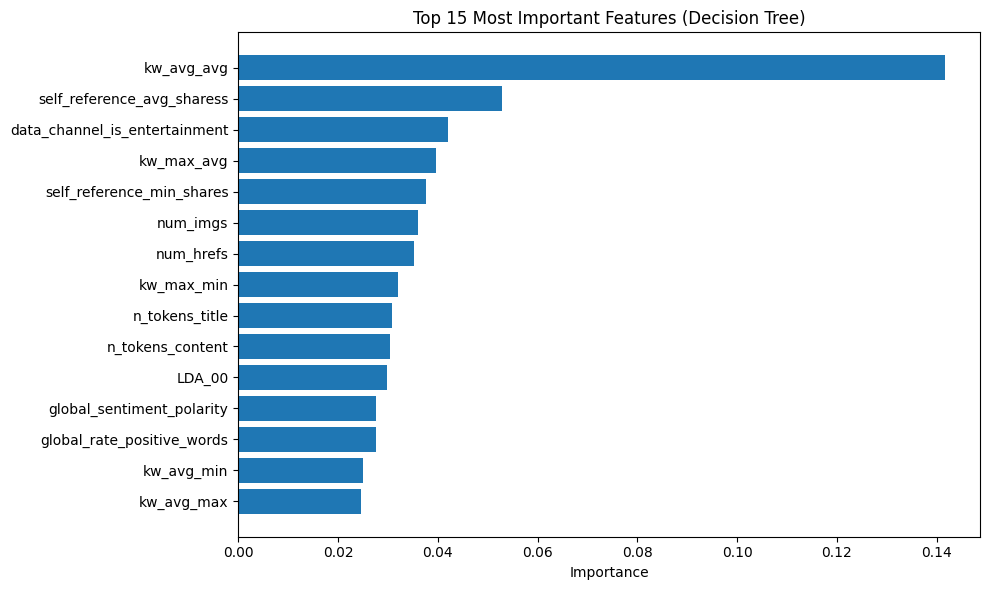

In [13]:
# Get feature importance from Decision Tree
feature_importance = dt_model.featureImportances.toArray()

# Create DataFrame with feature names and importance
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

print("\nTop 15 Most Important Features (Decision Tree):")
print(importance_df.head(15).to_string(index=False))

# Visualize top 15 features
plt.figure(figsize=(10, 6))
top_features = importance_df.head(15)
plt.barh(range(len(top_features)), top_features['Importance'])
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Importance')
plt.title('Top 15 Most Important Features (Decision Tree)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 9. Model Comparison and Visualization


MODEL COMPARISON - Part 1 (3 CFU)
              Model      AUC  Accuracy  F1-Score  Precision   Recall
Logistic Regression 0.704379  0.652078  0.649681   0.657887 0.652078
        Naive Bayes 0.481182  0.604133  0.576520   0.619499 0.604133
      Decision Tree 0.528091  0.607722  0.607289   0.611295 0.607722


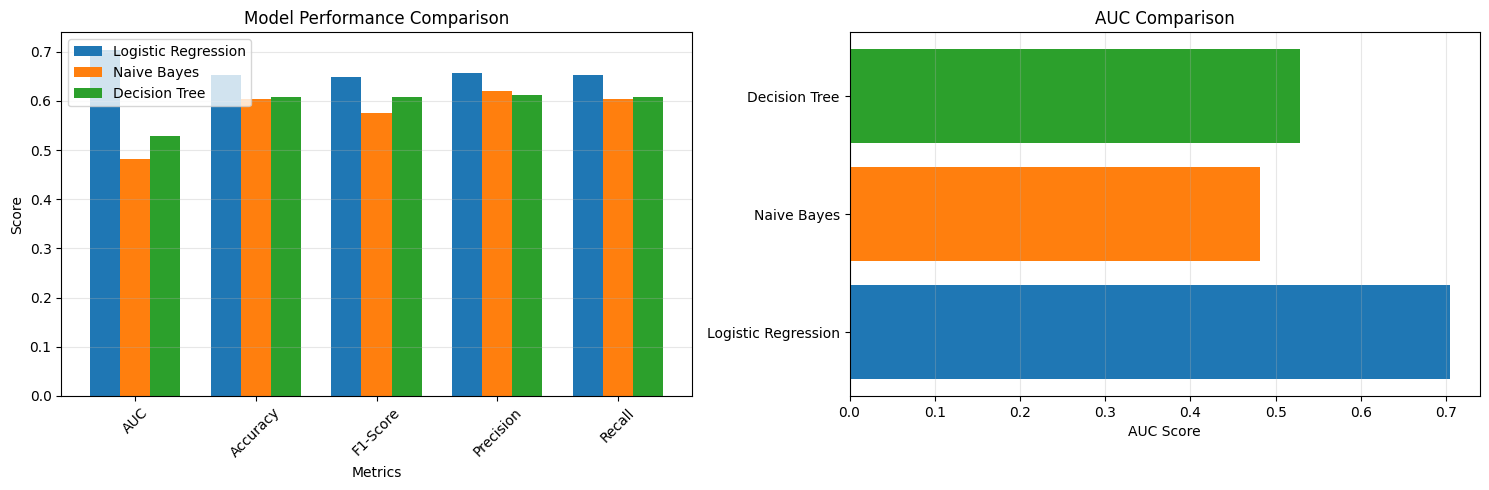

In [14]:
# Create comparison table
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Naive Bayes', 'Decision Tree'],
    'AUC': [lr_metrics['AUC'], nb_metrics['AUC'], dt_metrics['AUC']],
    'Accuracy': [lr_metrics['Accuracy'], nb_metrics['Accuracy'], dt_metrics['Accuracy']],
    'F1-Score': [lr_metrics['F1-Score'], nb_metrics['F1-Score'], dt_metrics['F1-Score']],
    'Precision': [lr_metrics['Precision'], nb_metrics['Precision'], dt_metrics['Precision']],
    'Recall': [lr_metrics['Recall'], nb_metrics['Recall'], dt_metrics['Recall']]
})

print("\n" + "="*80)
print("MODEL COMPARISON - Part 1 (3 CFU)")
print("="*80)
print(comparison_df.to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar chart for all metrics
metrics_to_plot = ['AUC', 'Accuracy', 'F1-Score', 'Precision', 'Recall']
x = np.arange(len(metrics_to_plot))
width = 0.25

for i, model in enumerate(['Logistic Regression', 'Naive Bayes', 'Decision Tree']):
    values = [comparison_df.loc[comparison_df['Model'] == model, metric].values[0] for metric in metrics_to_plot]
    axes[0].bar(x + i*width, values, width, label=model)

axes[0].set_xlabel('Metrics')
axes[0].set_ylabel('Score')
axes[0].set_title('Model Performance Comparison')
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(metrics_to_plot, rotation=45)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# AUC comparison
models = comparison_df['Model']
aucs = comparison_df['AUC']
axes[1].barh(models, aucs, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[1].set_xlabel('AUC Score')
axes[1].set_title('AUC Comparison')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 10. ROC Curves

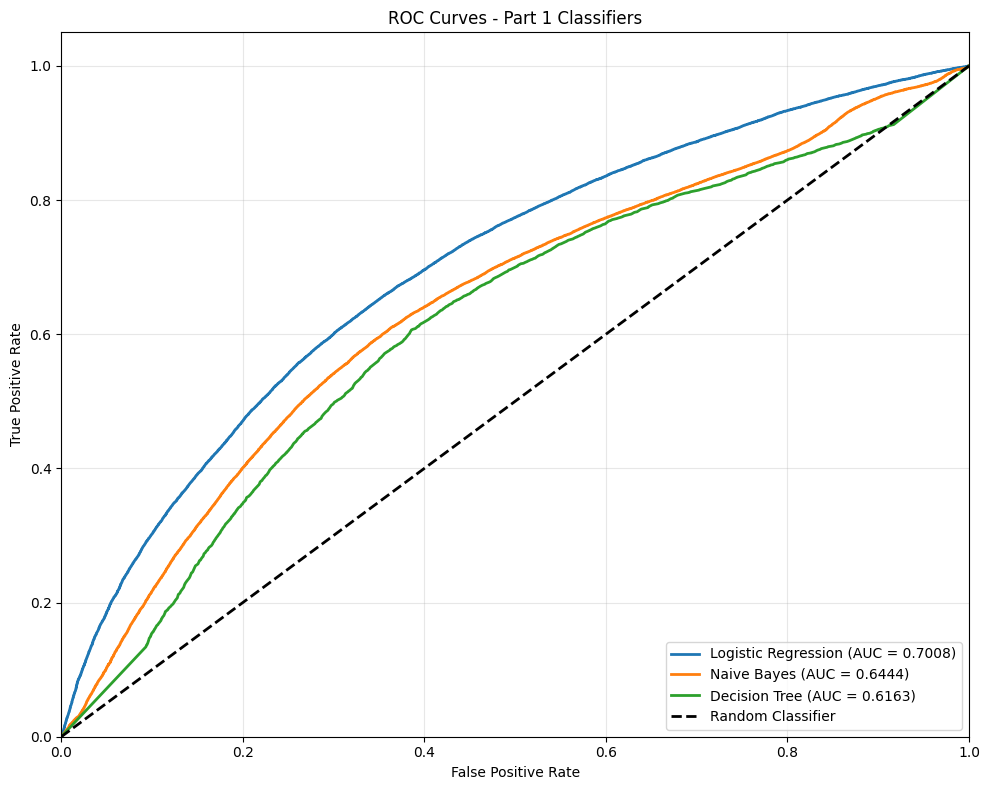

In [15]:
# Plot ROC curves for all models
plt.figure(figsize=(10, 8))

# Combine predictions from all windows for each model
models_data = [
    ('Logistic Regression', lr_predictions, '#1f77b4'),
    ('Naive Bayes', nb_predictions, '#ff7f0e'),
    ('Decision Tree', dt_predictions, '#2ca02c')
]

for model_name, predictions_list, color in models_data:
    # Combine all windows
    all_labels = []
    all_probs = []
    
    for pred_df in predictions_list:
        all_labels.extend(pred_df['label'].values)
        # Extract probability for positive class (index 1)
        probs = [p[1] if len(p) > 1 else p[0] for p in pred_df['probability'].values]
        all_probs.extend(probs)
    
    # Calculate ROC curve
    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    roc_auc = auc(fpr, tpr)
    
    # Plot
    plt.plot(fpr, tpr, color=color, lw=2, 
             label=f'{model_name} (AUC = {roc_auc:.4f})')

# Plot diagonal line
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Part 1 Classifiers')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Summary and Conclusions